# Analyse de survie du délai avant abandon d'une cohorte d'étudiants

## Synthèse

**Contexte.** Un service de recherche institutionnelle d'un collège de quatre ans veut comprendre *quand*, et pas seulement *si*, les étudiants partent. Une cohorte de primo-inscrits est suivie trimestre par trimestre depuis l'inscription ; certains obtiennent leur diplôme, d'autres abandonnent, et quelques-uns sont encore inscrits à la fermeture de la fenêtre d'observation. Parce que le devenir des étudiants encore inscrits est inconnu (censuré à droite), et parce que l'obtention du diplôme retire un étudiant du pool à risque sans constituer un abandon, une régression ordinaire réussite/échec jette l'information temporelle et biaise toute estimation qui ignore la censure. Le bon outil est l'**analyse de survie (délai avant événement)**, où l'événement d'intérêt est l'**abandon** et où l'horloge est mesurée en trimestres académiques d'inscription.

**Question métier.** Le **statut académique du premier trimestre** d'un étudiant (un indicateur d'alerte précoce) sépare-t-il les trajectoires de délai d'abandon de la cohorte, et quelles caractéristiques étudiantes déterminent le risque instantané d'abandon après ajustement ? Les réponses alimentent un système d'alerte précoce : les étudiants dont le risque estimé d'abandon est élevé devraient bénéficier d'un accompagnement dès leurs premiers trimestres, quand l'intervention est la moins coûteuse et la plus efficace.

**Approche.** Nous simulons en ligne une cohorte de 100 étudiants (aucune donnée externe), puis déroulons un flux de survie standard :

1. **PROC MEANS** dresse le profil des prédicteurs selon les trois devenirs observés (Diplômé / Abandon / encore Inscrit) pour confirmer que le signal simulé se comporte raisonnablement.
2. **PROC FREQ** croise le statut académique du premier trimestre avec le devenir, avec un test du khi-deux d'association.
3. **PROC UNIVARIATE** rapporte des centiles robustes du délai avant abandon par statut.
4. **PROC LIFETEST** estime les courbes d'abandon de Kaplan-Meier stratifiées par statut et exécute les tests d'égalité du **log-rank** et de **Wilcoxon**.
5. **PROC PHREG** ajuste un modèle multivarié à **risques proportionnels de Cox** pour le risque d'abandon, avec un effet `CLASS` codé par référence, la gestion des ex æquo d'Efron et des intervalles de confiance sur les limites de risque.

**Ce que montrent les données.** Sur les 100 étudiants simulés, **49 ont abandonné, 49 ont obtenu leur diplôme et 2 sont restés inscrits** au seuil de 12 trimestres. Les étudiants signalés en **avertissement académique** à leur premier trimestre (moyenne du premier trimestre inférieure à 2,5) abandonnent bien plus vite que les étudiants en règle : délai médian avant abandon **3,8 trimestres contre 8,7 trimestres**, une séparation que le test du log-rank confirme (khi-deux = 10,73, *p* = 0,0011). Le modèle de Cox identifie la moyenne du premier trimestre (rapport de risque 0,21 par point de moyenne, *p* < 0,0001), la moyenne du secondaire (HR 0,45, *p* = 0,027) et le statut de première génération (HR 2,03, *p* = 0,031) comme des déterminants ajustés significatifs de l'abandon, tandis que le statut de bourse Pell n'est pas significatif une fois la moyenne contrôlée (HR 0,95, *p* = 0,85).

> *Tous les chiffres sont illustratifs et générés à partir de données synthétiques ; ce ne sont pas de vrais dossiers étudiants. Cet environnement s'exécute sans licence, la cohorte est donc dimensionnée à 100 étudiants.*

## Sources de données

Toutes les données sont **synthétiques**, générées en ligne dans la première étape DATA avec `CALL STREAMINIT(20260611)` et la fonction `RAND`. Aucun fichier externe ni accès réseau. Une ligne par étudiant simulé.

**Jeu de données `inscriptions`** (100 lignes, une ligne par étudiant)

| Variable | Type | Description | Distribution génératrice |
|----------|------|-------------|--------------------------|
| `id_etudiant` | Num | Clé unique d'étudiant | séquence 1–100 |
| `premiere_gen` / `premiere_gen_lbl` | Num / Char | Indicateur de première génération (0/1) et libellé | Bernoulli, ~42 % |
| `pell` | Num | Indicateur de bourse Pell (besoin financier) (0/1) | Bernoulli, ~42 % |
| `programme` | Char | STEM / BUS / HUM | catégorielle (~42 % / 32 % / 26 %) |
| `moy_secondaire` | Num | Moyenne du secondaire (1,8–4,0) | Normale(3,00, 0,42), bornée |
| `moy_trim1` | Num | Moyenne collégiale du premier trimestre (0–4,0) | f(moy_secondaire, programme) + bruit normal |
| `statut` | Char | Statut académique du premier trimestre | `moy_trim1 < 2.5` → Avertissement académique, sinon En règle |
| `duree_trim` | Num | Trimestres d'inscription jusqu'à l'événement ou la censure | tirages Weibull concurrents ; plafonnés à 12 |
| `abandon` | Num | Indicateur d'événement d'abandon (1 = abandon, 0 = censuré) | dérivé |
| `devenir` | Char | Diplômé / Abandon / Inscrit | dérivé des tirages concurrents |

Un prédicteur linéaire latent sur l'échelle logarithmique relie le **taux d'abandon** de chaque étudiant à la moyenne du premier trimestre, à la moyenne du secondaire, au statut de première génération et au besoin financier, de sorte que les prédicteurs portent un signal véritable mais bruité. L'abandon et l'obtention du diplôme sont tirés comme des délais latents **concurrents** (Weibull) ; celui qui survient en premier à l'intérieur d'une fenêtre de 12 trimestres devient le devenir observé, et les étudiants qui atteignent le trimestre 12 sans ni l'un ni l'autre sont censurés à droite. Pour les modèles de survie, l'**événement est l'abandon** (`abandon = 1`) ; l'obtention du diplôme et l'inscription en cours sont toutes deux traitées comme de la censure (`abandon = 0`).

## 1. Simuler la cohorte d'étudiants

La première cellule construit une cohorte synthétique de 100 étudiants. Un prédicteur linéaire latent sur l'échelle logarithmique lie le taux d'abandon de chaque étudiant à la moyenne du premier trimestre, à la moyenne du secondaire, au statut de première génération et au statut Pell. L'abandon et l'obtention du diplôme sont générés comme des délais latents **concurrents** (tirages Weibull) ; celui qui survient en premier à l'intérieur d'une fenêtre d'observation de 12 trimestres devient le devenir observé, et les étudiants qui atteignent le trimestre 12 sans abandonner ni obtenir leur diplôme sont censurés à droite. Une moyenne du premier trimestre inférieure à 2,5 signale l'étudiant en **avertissement académique** — le signal d'alerte précoce que nous testons dans l'étape de survie. Les tirages aléatoires utilisent `CALL STREAMINIT` pour la reproductibilité et la fonction `RAND` sur les distributions uniforme, normale et Weibull. Des planchers et des bornes garantissent la plausibilité de chaque valeur (moyennes dans 0–4,0).

In [1]:
DONNÉES inscriptions;
    APPELER streaminit(20260611);
    LONGUEUR statut $32 premiere_gen_lbl $28 programme $4 devenir $16;

    ÉTIQUETTE id_etudiant      = "Identifiant étudiant"
          premiere_gen     = "Première génération (0/1)"
          premiere_gen_lbl = "Statut de première génération"
          pell             = "Bourse Pell (0/1)"
          programme        = "Programme d'études"
          moy_secondaire   = "Moyenne du secondaire"
          moy_trim1        = "Moyenne du premier trimestre"
          statut           = "Statut académique (1er trimestre)"
          duree_trim       = "Trimestres jusqu'à l'événement"
          abandon          = "Indicateur d'abandon (1=oui)"
          devenir          = "Devenir observé";

    FAIRE id_etudiant = 1 JUSQU_À 100;
        /* Indicateurs de première génération et de besoin financier */
        premiere_gen = (rand("uniform") < 0.42);
        SI premiere_gen ALORS premiere_gen_lbl = "Première génération";
        SINON                 premiere_gen_lbl = "Génération continue";
        pell = (rand("uniform") < 0.42);

        /* Programme d'études */
        v = rand("uniform");
        SI      v < 0.42 ALORS programme = "STEM";
        SINON SI v < 0.74 ALORS programme = "BUS";
        SINON                  programme = "HUM";

        /* Préparation académique et performance au premier trimestre */
        moy_secondaire = round(MIN(4.0, MAX(1.8, rand("normal", 3.00, 0.42))), 0.01);
        moy_trim1 = round(MIN(4.0, MAX(0.0,
                     0.55*moy_secondaire + 1.05 + 0.12*(programme="STEM")
                     + rand("normal", 0, 0.42))), 0.01);

        /* Alerte précoce : moyenne du 1er trimestre < 2,5 = avertissement */
        SI moy_trim1 < 2.5 ALORS statut = "Avertissement académique";
        SINON                   statut = "En règle";

        /* Risque d'abandon latent sur l'échelle log : moyenne plus basse,
           première génération et statut Pell relèvent le taux d'abandon. */
        eta = -1.05
             - 1.45*(moy_trim1 - 2.8)
             - 0.55*(moy_secondaire - 3.0)
             + 1.05*premiere_gen
             + 0.45*pell;
        taux_abandon = EXP(eta);

        /* Délais latents concurrents (trimestres) : abandon vs diplôme */
        t_abandon = rand("weibull", 1.2, 7.0) / MAX(0.30, taux_abandon);
        t_diplome = rand("weibull", 2.0, 7.5)
                 * EXP(-0.18*(moy_trim1 - 2.8));

        /* Fenêtre de censure administrative à 12 trimestres */
        censure_a = 12;
        SI t_abandon <= t_diplome AND t_abandon <= censure_a ALORS FAIRE;
            devenir = "Abandon";   abandon = 1; duree_trim = t_abandon;
        FIN;
        SINON SI t_diplome < t_abandon AND t_diplome <= censure_a ALORS FAIRE;
            devenir = "Diplômé"; abandon = 0; duree_trim = t_diplome;
        FIN;
        SINON FAIRE;
            devenir = "Inscrit";  abandon = 0; duree_trim = censure_a;
        FIN;
        duree_trim = round(duree_trim, 0.1);
        SORTIE;
    FIN;
    GARDER id_etudiant premiere_gen premiere_gen_lbl pell programme moy_secondaire
         moy_trim1 statut duree_trim abandon devenir;
EXÉCUTER;


NOTE: DATA inscriptions


NOTE: Wrote inscriptions (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Profil des prédicteurs selon le devenir observé

Avant la modélisation, nous confirmons que les prédicteurs simulés évoluent dans les directions attendues. **PROC MEANS** rapporte l'effectif, la moyenne, la dispersion et l'étendue de chaque prédicteur numérique au sein des trois devenirs observés.

La cohorte se répartit en **49 Diplômés / 49 Abandons / 2 encore Inscrits**. Les diplômés présentent une moyenne du premier trimestre plus élevée (moyenne **2,94** contre **2,54** pour les étudiants ayant abandonné) et une moyenne du secondaire plus élevée (**3,10** contre **2,90**) — exactement le gradient de préparation académique que l'analyse attend. Les deux étudiants encore inscrits se situent exactement au plafond de censure de 12 trimestres sur `duree_trim` (moyenne 12,00, écart-type 0), la censure à droite qu'une analyse d'attrition doit respecter. Parmi les étudiants ayant abandonné, l'événement arrive tôt : moyenne **3,31 trimestres**, allant de 0,1 à 8,9.

In [2]:
PROCÉDURE MOYENNES DONNÉES=inscriptions n mean std MIN MAX maxdec=2;
    CLASSE devenir;
    VAR moy_secondaire moy_trim1 duree_trim;
EXÉCUTER;

                                                  The MEANS Procedure

                                Analysis Variable : moy_secondaire Moyenne du secondaire

        Devenir observé           N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------------
        Abandon                      49           2.90           0.45           2.01           3.89
        Diplômé                      49           3.10           0.46           1.97           4.00
        Inscrit                       2           3.10           0.17           2.98           3.22
        -------------------------------------------------------------------------------------------

                               Analysis Variable : moy_trim1 Moyenne du premier trimestre

        Devenir observé           N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. L'indicateur d'alerte précoce suit-il le devenir ?

Le système d'alerte précoce signale en **avertissement académique** tout étudiant dont la moyenne du premier trimestre tombe sous 2,5. **PROC FREQ** croise cet indicateur avec le devenir observé et exécute un test du khi-deux d'association. Nous supprimons les pourcentages en ligne, en colonne et global (`NOROW NOCOL NOPERCENT`) pour que le tableau montre les effectifs bruts, et ajoutons les fréquences univariées de `statut` et du statut de première génération pour la composition de la cohorte.

Le tableau croisé est net : sur les **29** étudiants signalés en avertissement académique, **21 ont abandonné** et seulement 8 ont obtenu leur diplôme ; sur les **71** en règle, **41 ont obtenu leur diplôme** et 28 ont abandonné. L'association est significative (khi-deux = 9,21, ddl = 2, *p* = 0,0100 ; V de Cramér = 0,30). Notez l'**avertissement imprimé avec le tableau** : avec 100 étudiants et une maigre colonne « Inscrit » à deux diplômés, un tiers des cellules du tableau ont des effectifs attendus inférieurs à 5, la valeur *p* du khi-deux est donc fragile ici. Cette fragilité est précisément pourquoi les tests de survie des sections suivantes — qui utilisent l'information temporelle complète plutôt qu'un tableau 3×2 — constituent le test le plus fiable de l'effet du statut.

                                                   The FREQ Procedure

Table of Statut académique (1er trimestre) by Devenir observé

Statut académique (1er trimestre)  |   Abandon |   Diplômé |   Inscrit |      Total
-----------------------------------+-----------+-----------+-----------+-----------
Avertissement académique           |        21 |         8 |         0 |         29
-----------------------------------+-----------+-----------+-----------+-----------
En règle                           |        28 |        41 |         2 |         71
-----------------------------------+-----------+-----------+-----------+-----------
Total                              |        49 |        49 |         2 |        100

Statistics for Table of Statut académique (1er trimestre) by Devenir observé

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                2 9.2089       0.0100
Likeliho


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_statut_devenir.spec.json
NOTE: ODS plot written: freq_statut.spec.json
NOTE: ODS plot written: freq_premiere_gen_lbl.spec.json
NOTE: PROC FREQ statement used.


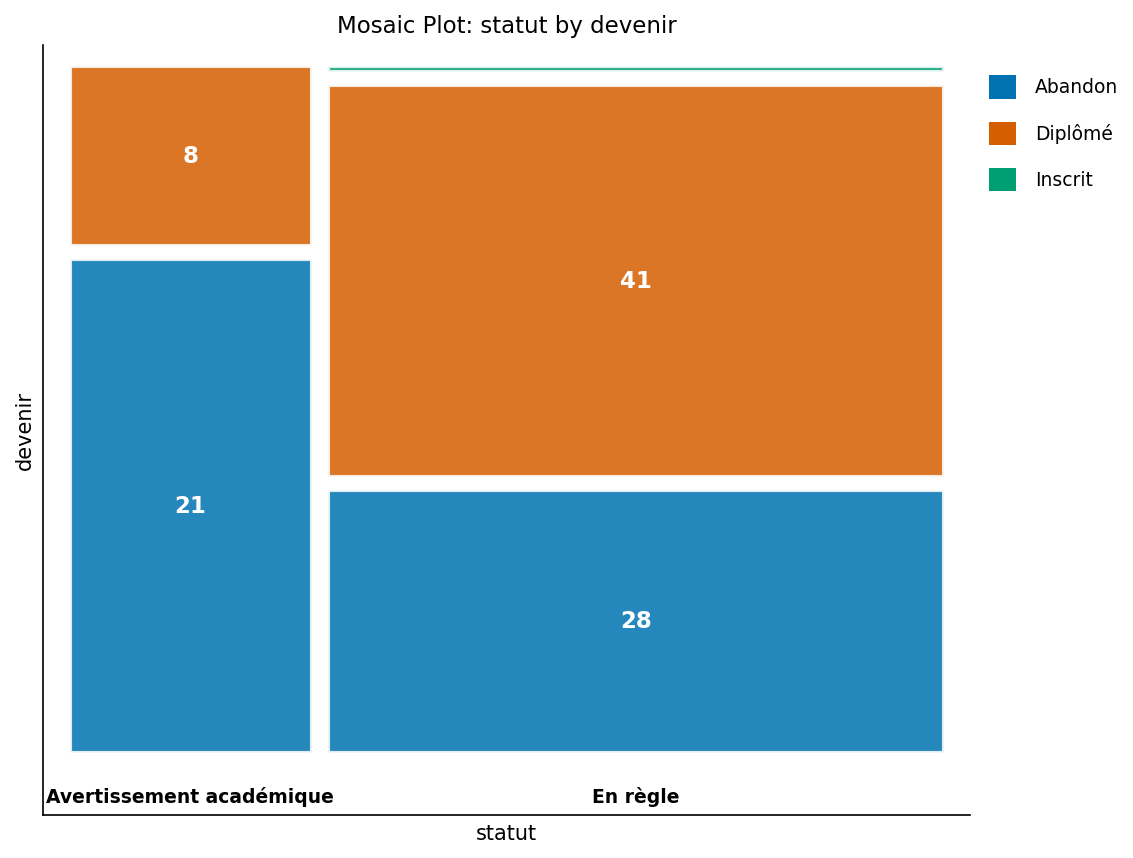

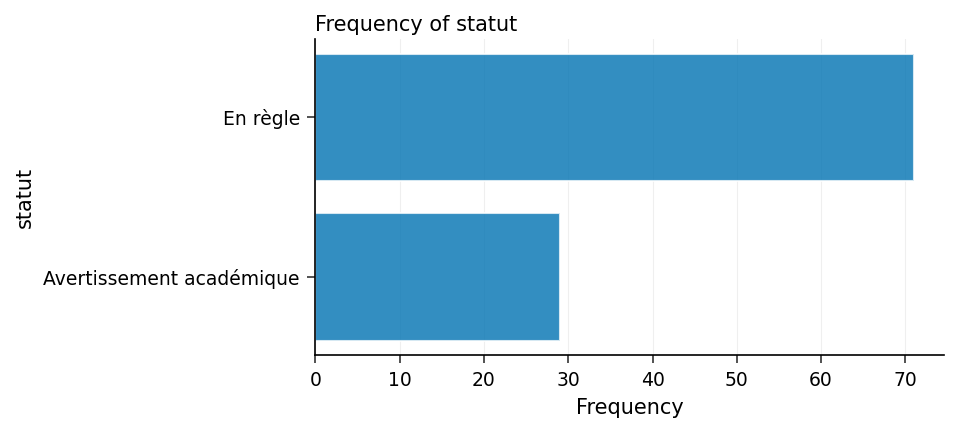

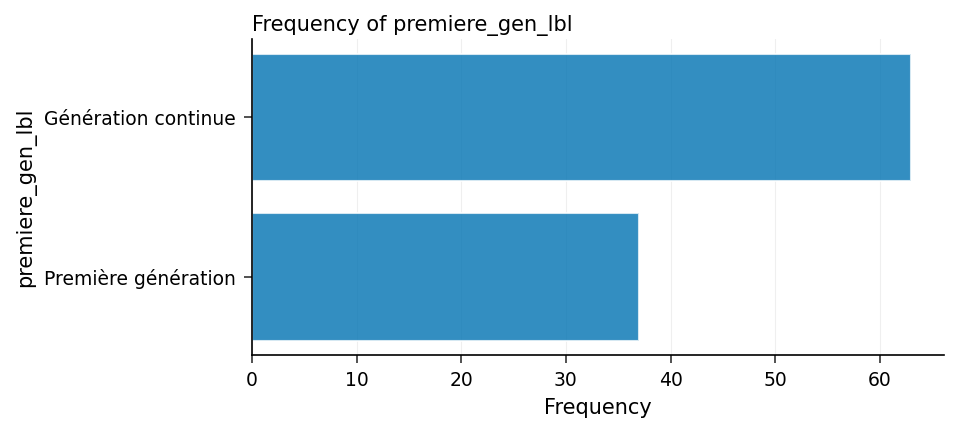

In [3]:
PROCÉDURE FRÉQUENCES DONNÉES=inscriptions;
    TABLES statut*devenir / chisq norow nocol nopercent;
    TABLES statut premiere_gen_lbl;
EXÉCUTER;

## 4. Quand les abandons surviennent-ils ? Centiles par statut

Pour les étudiants qui ont effectivement abandonné, *quand* sont-ils partis ? **PROC UNIVARIATE** (restreint à `abandon = 1`) rapporte les 10e, 50e (médiane) et 90e centiles du délai avant abandon au sein de chaque groupe de statut, écrits dans un jeu de données de sortie que nous imprimons ensuite. Cela décrit la dispersion du calendrier d'abandon sans supposer de distribution.

L'abandon médian parmi les étudiants qui sont partis survient autour du trimestre **2,4** (avertissement académique) contre **2,6** (en règle) — proches, car *conditionnellement à l'abandon*, les deux groupes tendent à partir tôt. L'effet du statut ne porte donc pas principalement sur *quand* un abandon survient, mais sur *combien* d'étudiants abandonnent et à quelle vitesse le pool à risque s'amenuise, ce que capturent précisément les courbes de Kaplan-Meier de la section suivante.

In [4]:
PROCÉDURE UNIVARIÉ DONNÉES=inscriptions SANS_IMPRESSION;
    OÙ abandon = 1;
    CLASSE statut;
    VAR duree_trim;
    SORTIE out=ref_abandon pctlpts=10 50 90 pctlpre=t_ p=;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=ref_abandon noobs ÉTIQUETTE;
    TITRE "Centiles du délai avant abandon (trimestres), par statut académique";
EXÉCUTER;
TITRE;

                          Centiles du délai avant abandon (trimestres), par statut académique                           

                   STATUT  T_10  T_50  T_90
Avertissement académique    0.2   2.4   7.9
En règle                    0.4   2.6   8.7




NOTE: PROC UNIVARIATE
NOTE: Output dataset ref_abandon has 2 observations and 4 variables.
NOTE: PROC PRINT data=ref_abandon

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


## 5. Courbes d'abandon de Kaplan-Meier par statut académique

Voici maintenant l'étape centrale de survie. **PROC LIFETEST** estime la fonction de survie **Kaplan-Meier** non paramétrique pour le *délai avant abandon*, traitant l'obtention du diplôme et l'inscription en cours comme de la censure (`abandon(0)` marque les observations censurées). Stratifier par `statut` produit une courbe d'abandon par groupe, et `TEST=(LOGRANK WILCOXON)` exécute deux tests complémentaires de la différence entre ces courbes : le test du **log-rank** pondère également tous les instants d'événement (sensible aux différences tardives), tandis que le test de **Wilcoxon** surpondère les instants d'événement précoces (sensible à l'attrition précoce). `PLOTS=SURVIVAL` demande le graphique superposé des courbes de survie.

Sur l'ensemble de la cohorte, il y a **49 événements d'abandon et 51 observations censurées**. Les courbes se séparent clairement : les étudiants en avertissement académique atteignent une **survie médiane (délai avant abandon) de 3,8 trimestres**, tandis que les étudiants en règle tiennent plus de deux fois plus longtemps (**8,7 trimestres**). Les deux tests rejettent l'égalité — **khi-deux du log-rank = 10,73, *p* = 0,0011 ; khi-deux de Wilcoxon = 7,66, *p* = 0,0056** — et les statistiques comparables nous indiquent que l'écart se maintient sur toute la fenêtre d'inscription, et pas seulement lors d'un pic précoce. Le graphique rend le message immédiat : la courbe orange d'avertissement académique chute fortement au cours des quatre premiers trimestres, tandis que la courbe bleue « en règle » reste élevée.

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       49
Censored                    51
Median Survival Time    3.8500

Stratum: Statut académique (1er trimestre) = Avertissement académique

                             N
--------------------  --------
Total                       29
Event                       21
Censored                     8
Median Survival Time    3.8000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  0.1000    0.9310     0.0471              29                 2
  0.2000    0.8966     0.0566              27                 1
  0.3000    0.8621     0.0640              26                 1
  1.2000    0.8276     0.0701              25                 1
  1.5000    0.7916     0.0758              23                 1
  1.6000  


NOTE: PROC LIFETEST data=inscriptions

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


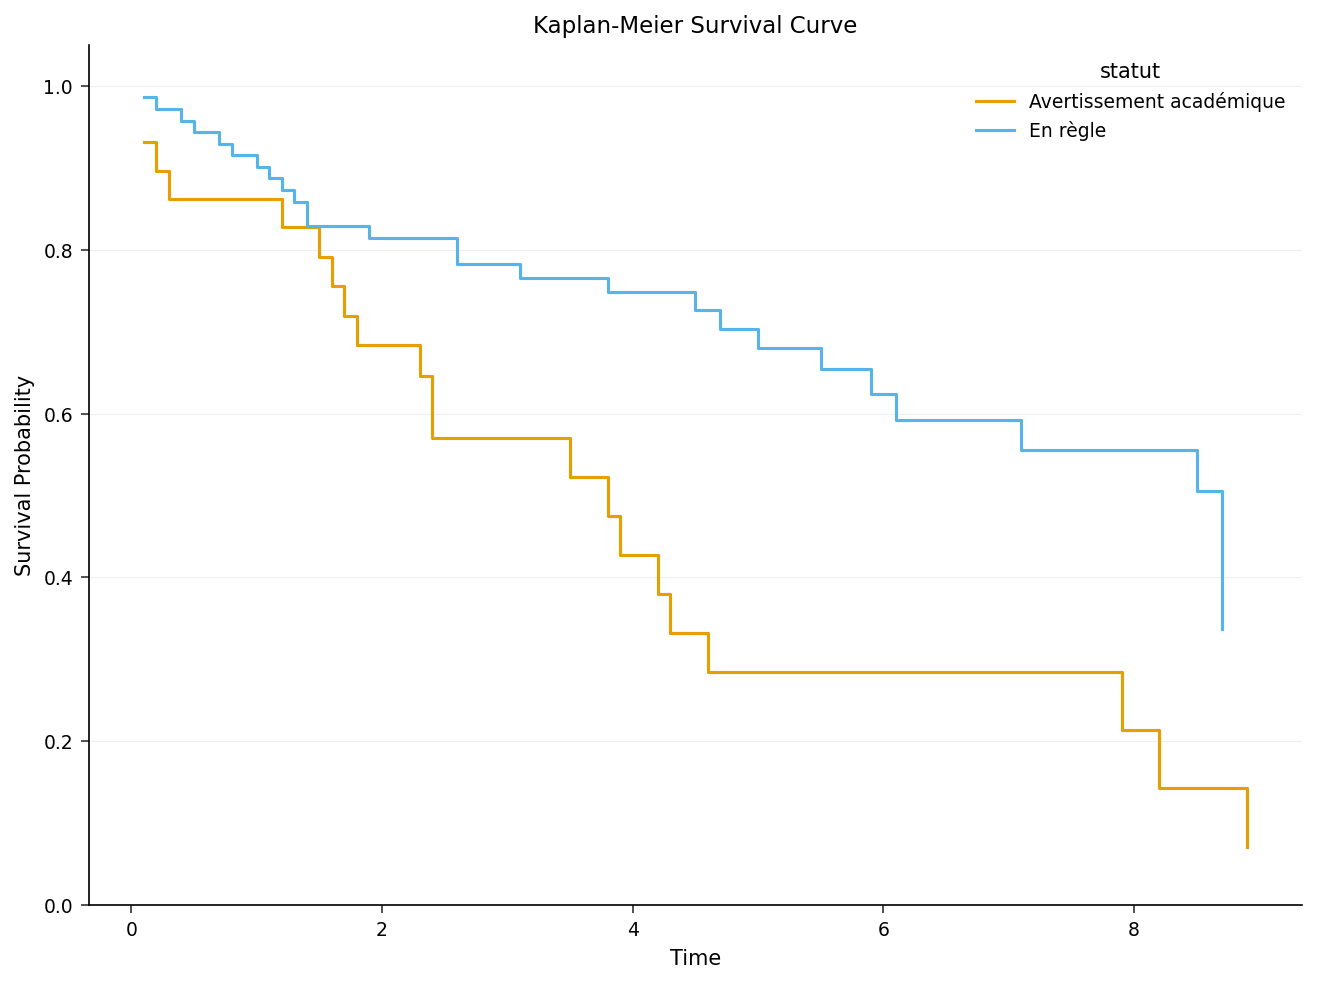

In [5]:
PROCÉDURE LIFETEST DONNÉES=inscriptions PLOTS=SURVIVAL METHOD=km;
    TIME duree_trim*abandon(0);
    STRATES statut / TEST=(logrank WILCOXON);
EXÉCUTER;

## 6. Modèle multivarié à risques proportionnels de Cox pour l'abandon

**PROC PHREG** ajuste le modèle à **risques proportionnels de Cox** pour le risque d'abandon, ajustant simultanément les prédicteurs. Demandes clés :

- `abandon(0)` fait de l'**abandon** l'événement et de tout le reste de la censure.
- `CLASS premiere_gen_lbl (ref="Génération continue") / param=ref` code par référence le facteur de première génération de sorte que son rapport de risque se lise par rapport aux étudiants de génération continue.
- `TIES=EFRON` est l'approximation recommandée de gestion des ex æquo quand plusieurs étudiants partent au même trimestre.
- `RL` ajoute des intervalles de confiance sur le rapport de risque (limites de risque).
- L'instruction `HAZARDRATIO` rapporte le contraste de première génération par rapport au groupe de référence.

Un rapport de risque supérieur à 1 signifie un abandon *plus rapide* (risque plus élevé) ; inférieur à 1 signifie un abandon *plus lent* (protecteur).

In [6]:
PROCÉDURE PHREG DONNÉES=inscriptions;
    CLASSE premiere_gen_lbl (REF="Génération continue") / PARAM=REF;
    MODÈLE duree_trim*abandon(0) = moy_secondaire moy_trim1 premiere_gen_lbl pell
          / TIES=efron rl;
    hazardratio "Première génération vs génération continue" premiere_gen_lbl / DIFF=REF;
EXÉCUTER;

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 49
-2 LOG L                    352.536
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     31.1053         4      <.0001
Wald                 29.9969         4      <.0001
Score (Log-Rank)     31.2100         4      <.0001

                                                  Analysis of Maximum Likelihood Estimates                                                   

Parameter                                      DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
---------------------------------------  --------  --------  --------------  ----------  ----------  ------------  --


NOTE: PROC PHREG data=inscriptions

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## 7. Interprétation et prochaines étapes

**Lecture de la sortie, de bout en bout :**

- **PROC MEANS** confirme le signal simulé : les étudiants diplômés présentent une moyenne du premier trimestre plus élevée (2,94 contre 2,54) et une moyenne du secondaire plus élevée (3,10 contre 2,90) que les étudiants ayant abandonné, et les étudiants encore inscrits se situent au plafond de 12 trimestres — la censure à droite que respectent les modèles de survie.
- **PROC FREQ** montre que l'indicateur d'avertissement académique du premier trimestre suit le devenir (21 des 29 étudiants signalés ont abandonné ; 41 des 71 étudiants en règle ont obtenu leur diplôme ; *p* = 0,0100), tout en signalant honnêtement que le khi-deux est fragile dans un tableau de 100 étudiants aux cellules clairsemées.
- **PROC UNIVARIATE** montre que *conditionnellement à l'abandon*, les deux groupes partent tôt (médiane ~2,4–2,6 trimestres) ; l'effet du statut porte sur combien d'étudiants abandonnent et à quelle vitesse le pool à risque s'amenuise, pas sur le calendrier de ceux qui partent.
- **PROC LIFETEST** livre le résultat principal : des courbes d'abandon de Kaplan-Meier qui se séparent nettement selon le statut (médiane 3,8 contre 8,7 trimestres ; log-rank *p* = 0,0011, Wilcoxon *p* = 0,0056). L'indicateur d'alerte précoce est un discriminant véritable et statistiquement soutenu du calendrier d'abandon.
- **PROC PHREG** quantifie l'effet ajusté de chaque prédicteur sur le risque d'abandon. Après ajustement, la **moyenne du premier trimestre est le facteur protecteur le plus fort** (rapport de risque 0,21 par point de moyenne, IC à 95 % 0,10–0,44, *p* < 0,0001) : chaque point de moyenne supplémentaire réduit le risque d'abandon d'environ quatre cinquièmes. La **moyenne du secondaire** est également protectrice (HR 0,45, IC à 95 % 0,22–0,91, *p* = 0,027). Les **étudiants de première génération** font face à environ le double du risque d'abandon de leurs pairs de génération continue à moyennes égales (HR 2,03, IC à 95 % 1,07–3,84, *p* = 0,031). Le **statut Pell n'est pas significatif** une fois la moyenne contrôlée (HR 0,95, IC à 95 % 0,53–1,69, *p* = 0,85) — un rappel utile qu'un facteur de risque brut peut s'estomper après ajustement. L'hypothèse nulle globale est nettement rejetée (khi-deux du rapport de vraisemblance = 31,11 à 4 ddl, *p* < 0,0001).

**Comment un établissement agirait à partir de ceci.** Le modèle de Cox produit un prédicteur linéaire par étudiant (score de risque) qui classe la cohorte selon le risque d'abandon ; les étudiants les plus à risque — faible moyenne du premier trimestre combinée au statut de première génération — sont dirigés vers un accompagnement d'alerte précoce dès leurs premiers trimestres, quand l'intervention est la moins coûteuse et la plus efficace. La comparaison de Kaplan-Meier fournit aux conseillers un critère unique et défendable qu'ils recueillent déjà à la fin du premier trimestre : le statut académique.

**Réserves et prolongements.** (1) Cette cohorte synthétique traite l'obtention du diplôme comme de la censure pour le modèle d'abandon ; avec des données réelles, l'obtention du diplôme et l'abandon sont de véritables **risques concurrents**, et une extension de risques concurrents (incidence cumulée) via `EVENTCODE=` de PROC PHREG éviterait de surestimer la probabilité d'abandon. (2) L'hypothèse des risques proportionnels devrait être vérifiée (`ASSESS PH` de PHREG ou résidus de Schoenfeld) avant de se fier à un rapport de risque unique sur tous les trimestres. (3) Les covariables variant dans le temps — moyenne trimestre par trimestre, changements d'aide financière, charge de cours — sont courantes dans les données de rétention et sont naturellement gérées par les instructions de programmation de PHREG. (4) La cohorte de 100 étudiants ici est dimensionnée au plafond d'exécution sans licence ; une analyse de production porterait sur plusieurs milliers d'étudiants, resserrant chaque intervalle de confiance. Validez toujours un score de risque déployé sur une cohorte réservée avant d'agir dessus opérationnellement.